In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import metrics.metrics as M

RECOMPUTED_PATH = "../temp_data/similarity_results_recomputed.parquet"
SOURCE_PATH = "../temp_data/PXD004732.parquet"

metric_keys = [
    "pearson_correlation",
    "spearman_correlation",
    "kendall_tau",
    "spectral_angle",
    "weighted_dot_product",
    "fit",
    "ruzicka_similarity_1",
    "ruzicka_similarity_2",
    "mse",
    "canberra_distance",
    "wasserstein",
    "bray_curtis",
    "mutual_information",
    "x_corr",
    "cosine_similarity",
]

TOL_PPM = 20

def match_spectra(mz1, int1, mz2, int2, tol_ppm=TOL_PPM):
    """
    Match peaks between two spectra within ppm tolerance.
    Returns aligned intensity vectors (only matched peaks).
    """
    mz1, int1 = np.array(mz1, dtype=float), np.array(int1, dtype=float)
    mz2, int2 = np.array(mz2, dtype=float), np.array(int2, dtype=float)

    matched_int1, matched_int2, matched_mz = [], [], []
    used2 = set()

    for i, m1 in enumerate(mz1):
        ppm_diffs = np.abs((mz2 - m1) / m1 * 1e6)
        candidates = np.where(ppm_diffs < tol_ppm)[0]
        candidates = [c for c in candidates if c not in used2]
        if len(candidates) == 0:
            continue
        best = candidates[np.argmin(ppm_diffs[candidates])]
        used2.add(best)
        matched_int1.append(int1[i])
        matched_int2.append(int2[best])
        matched_mz.append(m1)

    if len(matched_int1) == 0:
        return None, None, None

    return np.array(matched_mz), np.array(matched_int1), np.array(matched_int2)


def normalize_l2(arr):
    n = np.linalg.norm(arr)
    return arr / n if n > 0 else arr


# Only recompute if the file doesn't exist yet
if not Path(RECOMPUTED_PATH).exists():
    source_df = pd.read_parquet(SOURCE_PATH)
    print(f"Loaded source data: {source_df.shape}")

    records = []
    skipped = 0
    for _, row in source_df.iterrows():
        mz, i1, i2 = match_spectra(
            row["sequence_mz"], row["sequence_intensity"],
            row["ambiguous_sequence_mz"], row["ambiguous_sequence_intensity"],
        )
        if mz is None or len(mz) < 3:
            skipped += 1
            continue

        # Normalize to L2 for metrics that expect normalized input
        i1_norm = normalize_l2(i1)
        i2_norm = normalize_l2(i2)

        record = {
            "sequence1": row["sequence"],
            "sequence2": row["ambigous_sequence"],
            "sequence_raw_files": row["sequence_raw_files"],
            "ambiguous_sequence_raw_files": row["ambiguous_sequence_raw_files"],
            "n_matched_peaks": len(mz),
        }

        inp = {
            "intensity1": i1_norm,
            "intensity2": i2_norm,
            "mz1": mz,
            "mz2": mz,
            "mz": mz,
            "diagnostic_mz": np.array([]),
            "annotation1": np.array([]),
            "annotation2": np.array([]),
        }

        for key in metric_keys:
            try:
                record[key] = getattr(M, key)(**inp)
            except Exception:
                record[key] = np.nan

        records.append(record)

    result_df = pd.DataFrame(records)
    result_df.to_parquet(RECOMPUTED_PATH, index=False)
    print(f"Saved {len(result_df)} rows to {RECOMPUTED_PATH} ({skipped} skipped due to <3 matched peaks)")
else:
    print(f"Recomputed parquet already exists at {RECOMPUTED_PATH}, skipping recomputation.")
    result_df = pd.read_parquet(RECOMPUTED_PATH)
    print(f"Loaded: {result_df.shape}")

print(f"Columns: {result_df.columns.tolist()}")
result_df.head()


Recomputed parquet already exists at ../temp_data/similarity_results_recomputed.parquet, skipping recomputation.
Loaded: (192, 20)
Columns: ['sequence1', 'sequence2', 'sequence_raw_files', 'ambiguous_sequence_raw_files', 'n_matched_peaks', 'pearson_correlation', 'spearman_correlation', 'kendall_tau', 'spectral_angle', 'weighted_dot_product', 'fit', 'ruzicka_similarity_1', 'ruzicka_similarity_2', 'mse', 'canberra_distance', 'wasserstein', 'bray_curtis', 'mutual_information', 'x_corr', 'cosine_similarity']


,sequence1,sequence2,sequence_raw_files,ambiguous_sequence_raw_files,n_matched_peaks,pearson_correlation,spearman_correlation,kendall_tau,spectral_angle,weighted_dot_product,fit,ruzicka_similarity_1,ruzicka_similarity_2,mse,canberra_distance,wasserstein,bray_curtis,mutual_information,x_corr,cosine_similarity
0,LLEEEEEK,LIEEEEEK,01625b_GB2-TUM_first_pool_10_01_01-DDA-1h-R2:1...,01625b_GC2-TUM_first_pool_11_01_01-DDA-1h-R2:1...,5,0.523499,0.700000,0.600000,0.176846,0.416528,0.526741,0.420730,0.420730,0.109692,2.515296,77.573079,0.407727,0.637571,0.708814,0.274231
1,LIQGLVSK,LLQGLVSK,01625b_GB2-TUM_first_pool_10_01_01-DDA-1h-R2:2...,01625b_GD2-TUM_first_pool_12_01_01-DDA-1h-R2:2...,10,-0.301051,0.466667,0.422222,0.414696,0.131615,0.154998,0.203408,0.203408,0.121261,6.871363,45.055025,0.661946,1.861054,0.359505,0.606303
2,IQEELEK,IQEEIEK,01625b_GB2-TUM_first_pool_10_01_01-DDA-1h-R2:9...,01625b_GC1-TUM_first_pool_3_01_01-DDA-1h-R2:81...,9,0.077345,0.266667,0.166667,0.237251,0.548383,0.404362,0.367327,0.367327,0.080912,4.833347,35.775792,0.462708,1.361245,0.599539,0.364106
3,NSPPYILDILPDTYQHLR,NSPPYILDLLPDTYQHLR,01709a_GC1-TUM_first_pool_101_01_01-DDA-1h-R1:...,01709a_GD1-TUM_first_pool_102_01_01-DDA-1h-R1:...,75,0.828465,0.427482,0.290090,0.101646,0.788995,0.707302,0.455543,0.455543,0.004240,32.608056,122.238337,0.374058,0.963322,0.768067,0.158987
4,EYIERFR,EYLERFR,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2:15...,01625b_GB1-TUM_first_pool_2_01_01-DDA-1h-R2:17...,69,0.999290,0.864085,0.729753,0.000552,0.998653,0.998265,0.904206,0.904206,0.000025,11.497948,9.870371,0.050307,0.699329,0.965833,0.000868


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import sys
from pathlib import Path

# Load the recomputed observed data (metrics from metrics/metrics.py)
df = pd.read_parquet("../temp_data/similarity_results_recomputed.parquet")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape: (192, 20)
Columns: ['sequence1', 'sequence2', 'sequence_raw_files', 'ambiguous_sequence_raw_files', 'n_matched_peaks', 'pearson_correlation', 'spearman_correlation', 'kendall_tau', 'spectral_angle', 'weighted_dot_product', 'fit', 'ruzicka_similarity_1', 'ruzicka_similarity_2', 'mse', 'canberra_distance', 'wasserstein', 'bray_curtis', 'mutual_information', 'x_corr', 'cosine_similarity']


,sequence1,sequence2,sequence_raw_files,ambiguous_sequence_raw_files,n_matched_peaks,pearson_correlation,spearman_correlation,kendall_tau,spectral_angle,weighted_dot_product,fit,ruzicka_similarity_1,ruzicka_similarity_2,mse,canberra_distance,wasserstein,bray_curtis,mutual_information,x_corr,cosine_similarity
0,LLEEEEEK,LIEEEEEK,01625b_GB2-TUM_first_pool_10_01_01-DDA-1h-R2:1...,01625b_GC2-TUM_first_pool_11_01_01-DDA-1h-R2:1...,5,0.523499,0.700000,0.600000,0.176846,0.416528,0.526741,0.420730,0.420730,0.109692,2.515296,77.573079,0.407727,0.637571,0.708814,0.274231
1,LIQGLVSK,LLQGLVSK,01625b_GB2-TUM_first_pool_10_01_01-DDA-1h-R2:2...,01625b_GD2-TUM_first_pool_12_01_01-DDA-1h-R2:2...,10,-0.301051,0.466667,0.422222,0.414696,0.131615,0.154998,0.203408,0.203408,0.121261,6.871363,45.055025,0.661946,1.861054,0.359505,0.606303
2,IQEELEK,IQEEIEK,01625b_GB2-TUM_first_pool_10_01_01-DDA-1h-R2:9...,01625b_GC1-TUM_first_pool_3_01_01-DDA-1h-R2:81...,9,0.077345,0.266667,0.166667,0.237251,0.548383,0.404362,0.367327,0.367327,0.080912,4.833347,35.775792,0.462708,1.361245,0.599539,0.364106
3,NSPPYILDILPDTYQHLR,NSPPYILDLLPDTYQHLR,01709a_GC1-TUM_first_pool_101_01_01-DDA-1h-R1:...,01709a_GD1-TUM_first_pool_102_01_01-DDA-1h-R1:...,75,0.828465,0.427482,0.290090,0.101646,0.788995,0.707302,0.455543,0.455543,0.004240,32.608056,122.238337,0.374058,0.963322,0.768067,0.158987
4,EYIERFR,EYLERFR,01625b_GA1-TUM_first_pool_1_01_01-DDA-1h-R2:15...,01625b_GB1-TUM_first_pool_2_01_01-DDA-1h-R2:17...,69,0.999290,0.864085,0.729753,0.000552,0.998653,0.998265,0.904206,0.904206,0.000025,11.497948,9.870371,0.050307,0.699329,0.965833,0.000868


In [22]:
# Check I/L swap pairs
print("Sample sequence pairs:")
for i in range(min(5, len(df))):
    print(f"  {df['sequence1'].iloc[i]} vs {df['sequence2'].iloc[i]}")

print(f"\nTotal comparisons: {len(df)}")
print(f"Avg matched peaks per pair: {df['n_matched_peaks'].mean():.1f}")
print(f"Min matched peaks: {df['n_matched_peaks'].min()}, Max: {df['n_matched_peaks'].max()}")

# NOTE: PXD004732 contains only exact-match (same charge) I/L sibling pairs
# so no charge filtering is needed — all pairs are same-charge by construction.
print(f"\nAll {len(df)} pairs are same-charge I/L siblings from PXD004732")


Sample sequence pairs:
  LLEEEEEK vs LIEEEEEK
  LIQGLVSK vs LLQGLVSK
  IQEELEK vs IQEEIEK
  NSPPYILDILPDTYQHLR vs NSPPYILDLLPDTYQHLR
  EYIERFR vs EYLERFR

Total comparisons: 192
Avg matched peaks per pair: 51.2
Min matched peaks: 3, Max: 339

All 192 pairs are same-charge I/L siblings from PXD004732


In [23]:
# All pairs in the recomputed parquet are same-charge I/L siblings
df_same_charge = df.copy()
print(f"Total pairs: {len(df_same_charge)}")
print(list(df_same_charge.columns))


Total pairs: 192
['sequence1', 'sequence2', 'sequence_raw_files', 'ambiguous_sequence_raw_files', 'n_matched_peaks', 'pearson_correlation', 'spearman_correlation', 'kendall_tau', 'spectral_angle', 'weighted_dot_product', 'fit', 'ruzicka_similarity_1', 'ruzicka_similarity_2', 'mse', 'canberra_distance', 'wasserstein', 'bray_curtis', 'mutual_information', 'x_corr', 'cosine_similarity']


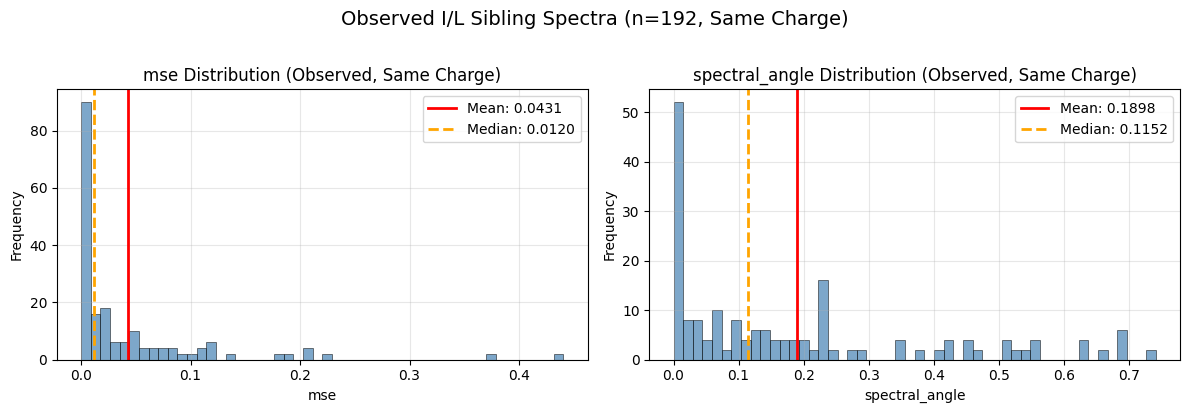

In [24]:
metrics_to_plot = ["mse", "spectral_angle"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(12, 4))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = df_same_charge[metric].dropna()

    # Histogram
    ax.hist(values, bins=50, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')

    ax.set_xlabel(f"{metric}")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{metric} Distribution (Observed, Same Charge)")
    if metric == "ruzicka_similarity_2":
        ax.legend(loc="upper left")
    else:    
        ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Observed I/L Sibling Spectra (n={len(df_same_charge)}, Same Charge)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

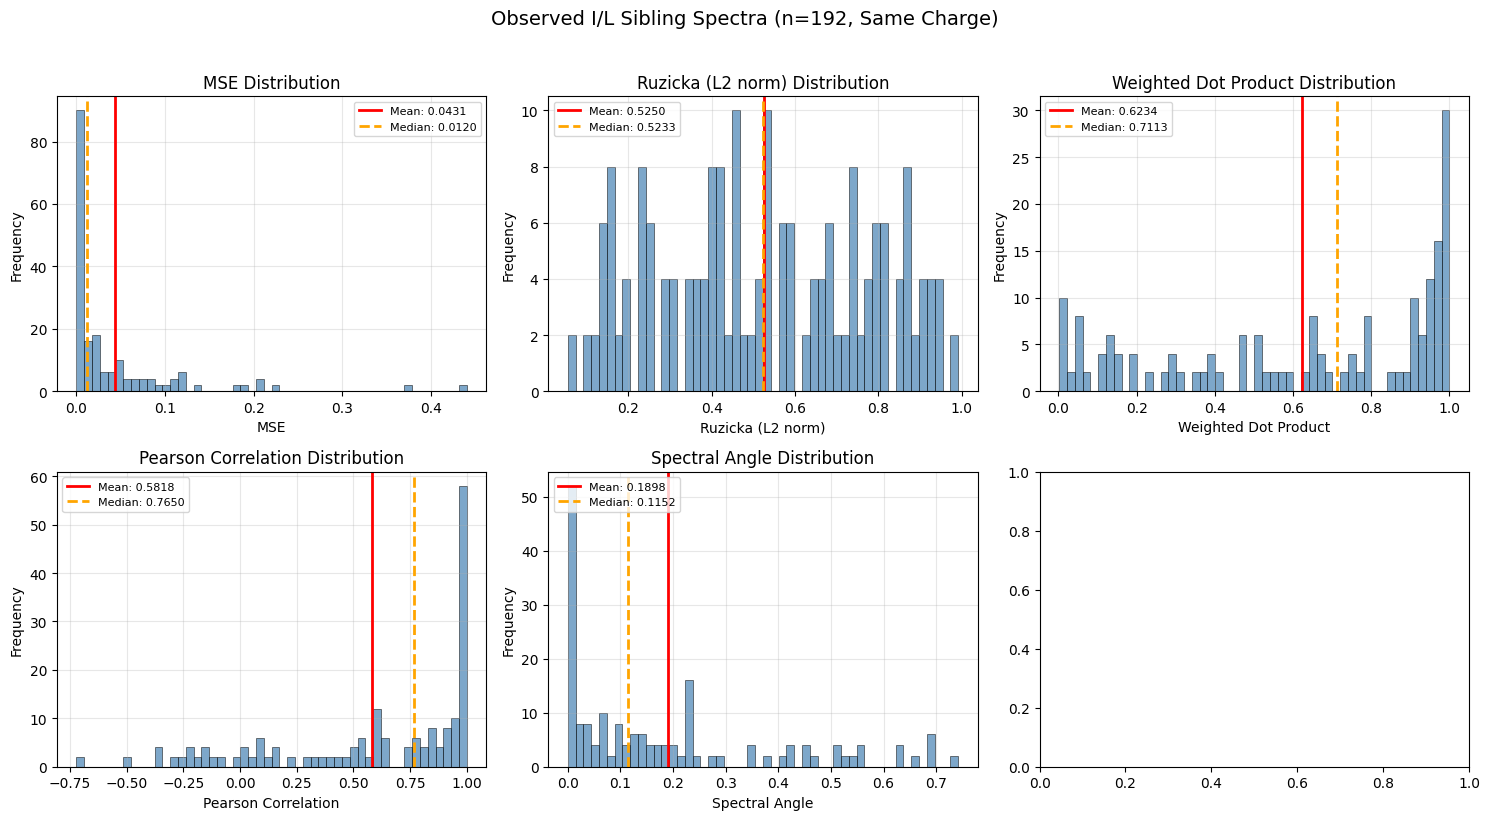

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metrics_grid = [
    ("mse", "MSE", "upper right"),
    ("ruzicka_similarity_2", "Ruzicka (L2 norm)", "upper left"),
    ("weighted_dot_product", "Weighted Dot Product", "upper left"),
    ("pearson_correlation", "Pearson Correlation", "upper left"),
    ("spectral_angle", "Spectral Angle", "upper left"),
    # ("gnps_score", "GNPS Score", "upper left"),
]

for idx, (metric, label, legend_loc) in enumerate(metrics_grid):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    values = df_same_charge[metric].dropna()

    # Histogram
    ax.hist(values, bins=50, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)

    # Add mean and median lines
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')

    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{label} Distribution")
    ax.legend(loc=legend_loc, fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Observed I/L Sibling Spectra (n={len(df_same_charge)}, Same Charge)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../temp_data/observed_il_metrics_figure.png", dpi=300, bbox_inches='tight')
plt.show()


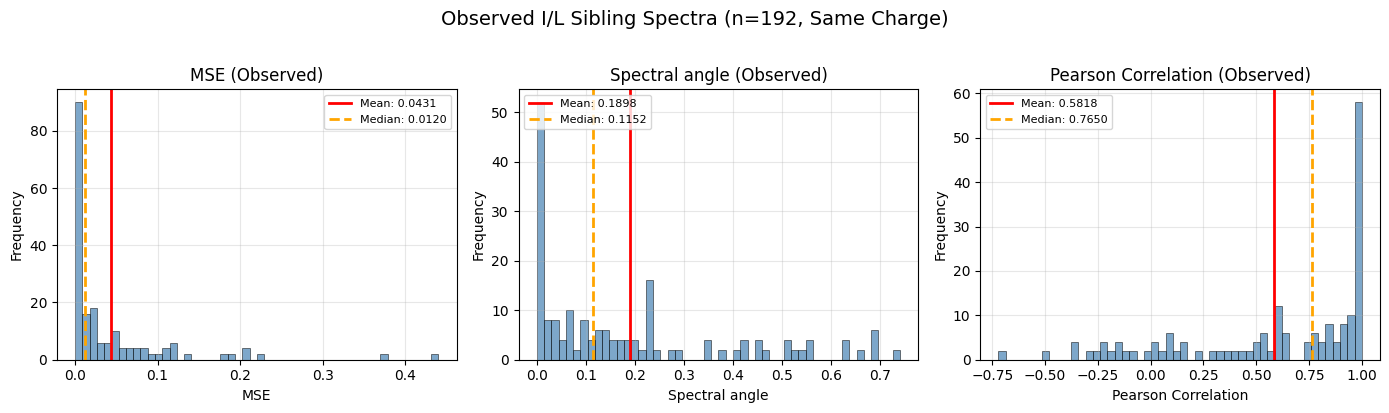

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# MSE
ax = axes[0]
values = df_same_charge["mse"].dropna()
ax.hist(values, bins=50, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("MSE")
ax.set_ylabel("Frequency")
ax.set_title("MSE (Observed)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Spectral angle
ax = axes[1]
values = df_same_charge["spectral_angle"].dropna()
ax.hist(values, bins=50, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("Spectral angle")
ax.set_ylabel("Frequency")
ax.set_title("Spectral angle (Observed)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Pearson Correlation
ax = axes[2]
values = df_same_charge["pearson_correlation"].dropna()
ax.hist(values, bins=50, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
mean_val, median_val = values.mean(), values.median()
ax.axvline(mean_val, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.4f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.4f}')
ax.set_xlabel("Pearson Correlation")
ax.set_ylabel("Frequency")
ax.set_title("Pearson Correlation (Observed)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f"Observed I/L Sibling Spectra (n={len(df_same_charge)}, Same Charge)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../temp_data/observed_il_simplified_figure.png", dpi=300, bbox_inches='tight')
plt.show()


In [27]:
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from metrics.get_metrics import metrics_comparison

# Load the predicted intensity data
peptides_predictions = pd.read_csv("../temp_data/peptides_predictions.csv")
peptides_switch_predictions = pd.read_csv("../temp_data/peptides_switch_predictions.csv")

# Create ID column for predictions (needed for metrics_comparison)
peptides_predictions["seq_charge"] = (
    peptides_predictions["peptide_sequences"]
    + "/"
    + peptides_predictions["precursor_charges"].astype(str)
)
unique_combinations = peptides_predictions["seq_charge"].unique()
seq_charge_to_id = {combo: i for i, combo in enumerate(unique_combinations)}
peptides_predictions["ID"] = peptides_predictions["seq_charge"].map(seq_charge_to_id)

# For switched predictions, we need to map back to original sequences
# Load original peptides to create the mapping
from seq_utils.fasta_to_peptides import create_tryptic_peptides
from seq_utils.peptide import remove_non_il, remove_ux_containing, switch_random_il

fasta_file = "../fasta/UP000005640_9606.fasta"
peptides = create_tryptic_peptides(fasta_file)
peptides = remove_non_il(peptides)
peptides = remove_ux_containing(peptides)
peptides = np.array(peptides)

# Sample same peptides as figure1
rng = np.random.default_rng(42)
indices = rng.choice(len(peptides), size=20000, replace=False)
peptides = peptides[indices]
peptides_switched = np.array([switch_random_il(peptide) for peptide in peptides])

# Create mapping from switched to original
switched_to_orig = dict(zip(peptides_switched, peptides))

peptides_switch_predictions["seq_charge"] = (
    peptides_switch_predictions["peptide_sequences"]
    + "/"
    + peptides_switch_predictions["precursor_charges"].astype(str)
)
peptides_switch_predictions["orig_seq_charge"] = peptides_switch_predictions.apply(
    lambda row: switched_to_orig.get(row["peptide_sequences"], row["peptide_sequences"])
    + "/"
    + str(row["precursor_charges"]),
    axis=1,
)
peptides_switch_predictions["ID"] = peptides_switch_predictions["orig_seq_charge"].map(seq_charge_to_id)

# Compute similarity metrics for predicted data
score_df_predicted = metrics_comparison(peptides_predictions, peptides_switch_predictions)
print(f"Predicted data: {len(score_df_predicted)} comparisons")
print(f"Observed data (same charge): {len(df_same_charge)} comparisons")

Predicted data: 751 comparisons
Observed data (same charge): 192 comparisons


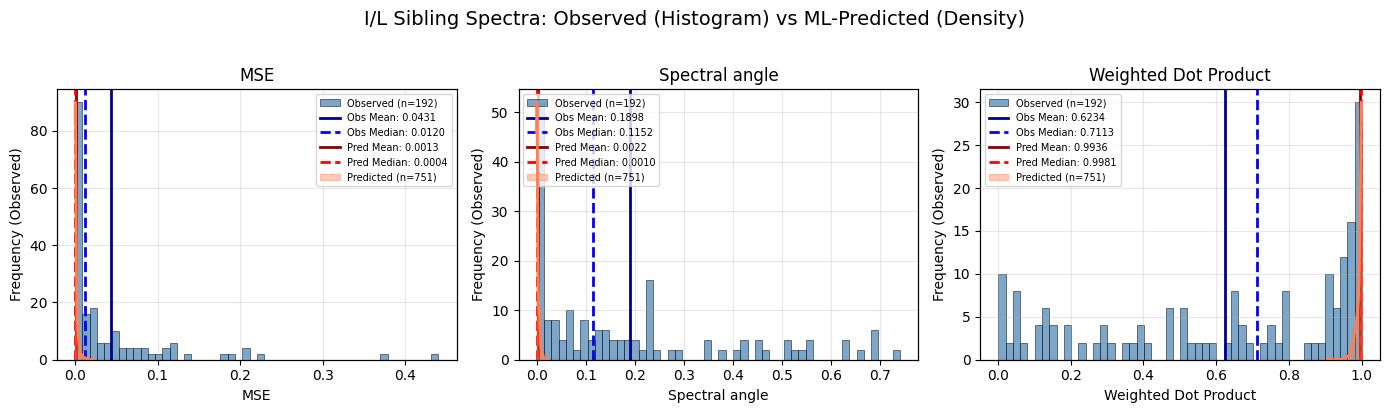

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_config = [
    ("mse", "MSE", "upper right"),
    ("spectral_angle", "Spectral angle", "upper left"),
    ("weighted_dot_product", "Weighted Dot Product", "upper left"),
]

for idx, (metric, label, legend_loc) in enumerate(metrics_config):
    ax = axes[idx]
    
    # Observed data (same charge) - histogram with counts
    obs_values = df_same_charge[metric].dropna()
    ax.hist(obs_values, bins=50, alpha=0.7, color='steelblue', edgecolor='black', 
            linewidth=0.5, label=f'Observed (n={len(obs_values)})')
    
    # Add mean/median for observed
    obs_mean = obs_values.mean()
    obs_median = obs_values.median()
    ax.axvline(obs_mean, color='darkblue', linestyle='-', linewidth=2, label=f'Obs Mean: {obs_mean:.4f}')
    ax.axvline(obs_median, color='blue', linestyle='--', linewidth=2, label=f'Obs Median: {obs_median:.4f}')
    
    # Predicted data - density on secondary y-axis (hidden)
    pred_values = score_df_predicted[metric].dropna()
    ax2 = ax.twinx()
    
    # KDE for predicted data
    pred_kde = stats.gaussian_kde(pred_values)
    pred_x = np.linspace(pred_values.min(), pred_values.max(), 200)
    pred_y = pred_kde(pred_x)
    ax2.fill_between(pred_x, pred_y, alpha=0.4, color='coral', label=f'Predicted (n={len(pred_values)})')
    ax2.plot(pred_x, pred_y, color='coral', linewidth=2)
    
    # Add mean/median for predicted
    pred_mean = pred_values.mean()
    pred_median = pred_values.median()
    ax.axvline(pred_mean, color='darkred', linestyle='-', linewidth=2, label=f'Pred Mean: {pred_mean:.4f}')
    ax.axvline(pred_median, color='red', linestyle='--', linewidth=2, label=f'Pred Median: {pred_median:.4f}')
    
    # Hide the secondary y-axis ticks and labels
    ax2.set_yticks([])
    ax2.set_ylabel('')
    # Force the secondary y-axis to start at 0
    ax2.set_ylim(bottom=0)
    
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency (Observed)")
    ax.set_title(f"{label}")
    
    # Combine legends from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc=legend_loc, fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("I/L Sibling Spectra: Observed (Histogram) vs ML-Predicted (Density)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../temp_data/observed_vs_predicted_overlay.png", dpi=300, bbox_inches='tight')
plt.show()